In [1]:
%load_ext autoreload
%autoreload 2

# HCA-GPT: How to train a GPT from scratch

In this notebook we will go through the steps needed to implement a GPT from scratch and train it - to the extent possible - on a consumer laptop. We will start by parsimg a piece of text, translating it into tokens and implementing a method splitting the tokens into batches to be used during training.

Next, we will implement the building blocks of the GPT model. This includes of course the multi-head attention blocks and also feed-forward and layer normalization modules. We will combine all of these into the final GPT model.
 
The fairytale "The Nightengale" by H. C. Andersen will be used as training text. The artificial, mechanical nightengale seems a fitting analogy of the pattern recognition employed by GPTs. After training, our GPT should be able to generate text resembling mid-1800 Danish or at least fractions of the fairytale.

This notebook is roughly based on [Build A Larger Language Model (from scratch)](https://sebastianraschka.com/llms-from-scratch/) by Sebastian Raschka and I highly recommend the book.

## 1. Translate the text into tokens

GPTs do not work directly on raw text, instead the text must first be split into small chunks called tokens. The allowed tokens are predefined and given in a vocabolary of a fixed size. Since the vocabulary is fixed in size, each token is associated with an integer token id. Hence, the text is encoded into a string of intergers and can be losslessly be decoded back into the original text.

We will use the GPT2 tokenizer which is based on [Byte Pair Encoding](https://en.wikipedia.org/wiki/Byte-pair_encoding).



We read in the fairytale and see that it contains 18,136 characters:

In [2]:
with open('../text/nattergalen.txt', 'r', encoding='utf-8') as f:
    text = f.read()

print(text[:88])
print('Number of characters:', len(text))

I China veed Du jo nok er Keiseren en Chineser, og Alle de han har om sig ere Chinesere.
Number of characters: 18136


Next we instantiate the tokenizer and we see that it works on vocabulary of 50,257 unique tokens:

In [3]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print('Vocabulary size:', tokenizer.n_vocab)


Vocabulary size: 50257


In [61]:
def show_token(i):
    try:
        u = tokenizer.token_byte_values()[i].decode('utf-8')
    except:
        u = '?'
    print(u)

for i in range(10_000, 10_005):
    show_token(i)

print('-'*100)

for i in range(50_000, 50_005):
    show_token(i)


 Razer
 Razor
 Rd
 Re
 Reach
----------------------------------------------------------------------------------------------------
カ
ガ
キ
ギ
ク


We can see that the tokenizer is focused on English words, however, it will be able to encode any language as it will simply break down unknown words into smaller chunks untill it finds a matching token in the vocabulary.

Now let's encode our text giving us 7,621 tokens:

In [5]:
tokens = tokenizer.encode(text)
print(len(tokens))

7621


We can decode the tokens back to the original text:

In [6]:
print('Token Id | Token')
print('---------+---------')
for i in range(10):
    token_id = tokens[i]
    token = tokenizer.decode([token_id])
    print(f'{token_id:<8} | "{token}"')

print()
print(tokenizer.decode(tokens)[0:100])
    

Token Id | Token
---------+---------
40       | "I"
2807     | " China"
1569     | " ve"
276      | "ed"
10343    | " Du"
2525     | " jo"
299      | " n"
482      | "ok"
1931     | " er"
3873     | " Ke"

I China veed Du jo nok er Keiseren en Chineser, og Alle de han har om sig ere Chinesere. Det er nu m


## 2. Preparing the text for training
The [make_data_loader](github.com) function takes some text and organises it into batches of input and target tokens. Let's give it a run to see how it works:

In [71]:
from sturnus.util import make_data_loader

data_loader = make_data_loader(text, batch_size=2, length_max=4, stride=4, shuffle=False)

print('All tokens: ', tokens)

for i, (input_tokens, target_tokens) in enumerate(data_loader):
    if i > 1:
        break

    print(f'Batch {i}:')
    print('input_tokens:\n', input_tokens)
    print('target_tokens:\n', target_tokens)
    print()




All tokens:  [40, 2807, 1569, 276, 10343, 2525, 299, 482, 1931, 3873, 271, 14226, 551, 609, 1127, 263, 11, 267, 70, 978, 293, 390, 289, 272, 3971, 39030, 43237, 304, 260, 609, 1127, 567, 13, 4614, 1931, 14364, 582, 469, 317, 283, 9785, 268, 11, 1450, 655, 4587, 1640, 1931, 1062, 410, 21241, 4372, 379, 289, 24172, 260, 5590, 273, 2013, 11, 277, 24172, 81, 582, 308, 10671, 647, 2853, 0, 3873, 271, 567, 5907, 32026, 1401, 1062, 778, 21241, 13655, 328, 4169, 1312, 4643, 6559, 11, 308, 504, 365, 267, 70, 257, 335, 417, 274, 6580, 25912, 600, 20139, 5276, 391, 11, 473, 64, 479, 455, 16575, 11, 1450, 473, 64, 1341, 73, 24172, 17034, 11, 473, 64, 47930, 365, 4604, 83, 379, 374, 24172, 260, 410, 276, 11, 379, 582, 17266, 265, 660, 2760, 298, 4604, 256, 496, 43237, 1312, 363, 83, 13, 314, 21425, 473, 3609, 582, 390, 329, 4625, 4604, 4169, 1086, 296, 1706, 11, 267, 70, 410, 276, 390, 477, 263, 1050, 21241, 13655, 328, 4169, 1401, 4587, 12207, 316, 311, 24172, 6780, 41582, 482, 6122, 11, 4587, 479

We asked for a batch size of 2 with a maximum length of 4 tokens per example and that is what we got. The first batch contain an input and a target tensor both of shape (2,4). We see that the target tokens are merely shifted one place to the right compared to the input tokens. This allows us to train the model to predict the second token when only given the first and to predict the third token when given the first and second tokens as input etc.

The stride of 4 ensures that there are 4 tokens between each example. This corresponds to the maximum lenght and there is therefore no overlap between examples.

## 3. Building blocks for our GPT implementation
### 3.1 Embedding vectors

Next we will add embedding vectors. Embedding vectors are vectors with learnable values representing each token value. So for each token in our vocabulary we will have a learnable embedding vector containing continuos values. We saw above that the BPE tokenizer has a vocabulry of 50,257 possible tokens. We will set up each embedding vector to hold 256 parameters so total we will need 50257 times 256 parameters:

In [8]:
import torch

vocab_size = 50257
output_dim = 256

torch.manual_seed(42)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
print(embedding_layer)

Embedding(50257, 256)


In [9]:
max_length = 4
data_loader = make_data_loader(
    text,
    batch_size=8,
    length_max=max_length,
    stride=max_length,
    shuffle=False
)

# inputs dim: [8, 4]
# output dim: [8, 4]

data_iter = iter(data_loader)
input_tokens, target_tokens = next(data_iter)

print(input_tokens.shape)
print(target_tokens.shape)



torch.Size([8, 4])
torch.Size([8, 4])


In [10]:
token_embeddings = embedding_layer(input_tokens)
print(token_embeddings.shape)

torch.Size([8, 4, 256])


So the token embeddings have the shape [batch_size, max_length, embedding_dim] = [8, 4, 256].

The `token_embeddings` do not contain any information on the positions of the individual tokens in the text. However, context is of course important when training a language model. So in order to include information about position, we will add positional embedding vector that is also learnable:

In [11]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)
pos_embeddings = pos_embedding_layer(torch.arange(context_length))
print(pos_embeddings.shape)
print(pos_embeddings)

torch.Size([4, 256])
tensor([[-0.6129,  0.4676,  0.9984,  ..., -0.2500, -0.3666, -0.7455],
        [ 0.8688, -0.0092,  0.7246,  ..., -1.0887, -0.6005, -0.0853],
        [ 0.5725,  0.6426, -0.0487,  ..., -0.7033, -0.8392,  1.6090],
        [ 0.3062,  0.4805,  0.0771,  ...,  0.6517,  1.5563, -0.3937]],
       grad_fn=<EmbeddingBackward0>)


In [12]:
input_embeddings = token_embeddings + pos_embeddings # [8, 4, 256] + [4, 256] = [8, 4, 256]
print(input_embeddings.shape)

torch.Size([8, 4, 256])


The `pos_embeddings` tensor is broadcastet along the batch dimennsion of the `token_embeddings` tensor.

### 3.2 Self-attention

#### Simple example

In [14]:
inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

In [15]:
inputs.shape

torch.Size([6, 3])

Calculate attention scores for input 2 using dot products:

In [16]:
query = inputs[1]
attn_scores_2 = torch.empty(inputs.shape[0])

for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query)

In [17]:
attn_scores_2  

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])

Calculate attention weights using soft max normailization:

In [18]:
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
print("Attention weights:", attn_weights_2)
print("Sum:", attn_weights_2.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


Calculate context vector for input 2 by summing up all inputs weighted by the attention weights for input 2:

In [19]:
context_vec_2 = torch.zeros(query.shape)

for i, x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i] * x_i

print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


#### Let's repeat the above calculation but for all inputs

In [20]:
attention_scores = inputs @ inputs.T  # [6, 3] @ [6, 3].T = [6, 6]
attention_weights = torch.softmax(attention_scores, dim=-1)
print(attention_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [21]:
attention_weights.sum(dim=-1)

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [22]:
all_context_vecs = attention_weights @ inputs  # [6, 6] @ [6, 3] = [6, 3]
print(all_context_vecs)
print(all_context_vecs.shape)


tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])
torch.Size([6, 3])


### Self-attention with trainable weights

Scaled dot-product attention.

First a simple example:

In [23]:
X_2 = inputs[1]
d_in = inputs.shape[1]
d_out = 2

In [24]:
torch.manual_seed(123)
W_Q = torch.nn.Parameter(torch.randn(d_in, d_out), requires_grad=False)
W_K = torch.nn.Parameter(torch.randn(d_in, d_out), requires_grad=False)
W_V = torch.nn.Parameter(torch.randn(d_in, d_out), requires_grad=False)

# query_2 = X_2 @ W_Q 
# key_2 = X_2 @ W_K 
# value_2 = X_2 @ W_V
# print(query_2)
# print(key_2)
# print(value_2)





In [25]:
keys = inputs @ W_K  # [6, 3] @ [3, 2] = [6, 2]
values = inputs @ W_V  # [6, 3] @ [3, 2] = [6, 2]

print(keys)
print(values.shape)

tensor([[-0.1823, -0.6888],
        [-0.1142, -0.7676],
        [-0.1443, -0.7728],
        [ 0.0434, -0.3580],
        [-0.6467, -0.6476],
        [ 0.3262, -0.3395]])
torch.Size([6, 2])


In [26]:
# keys_2 = keys[1]
# print(keys_2.shape)
# attn_score_22 = query_2.dot(keys_2)
# print(attn_score_22)





In [27]:
attn_scores_2 = query_2 @ keys.T  # [1, 2] @ [6, 2].T = [1, 6]

NameError: name 'query_2' is not defined

In [28]:
print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [29]:
d_key = keys.shape[-1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_key ** 0.5, dim=-1)
print(attn_weights_2)






tensor([0.1476, 0.2164, 0.2134, 0.1365, 0.1240, 0.1621])


In [30]:
context_vector_2 = attn_weights_2 @ values  # [1, 6] @ [6, 2] = [1, 2]

In [31]:
print(context_vector_2)

tensor([0.3042, 0.4118])


Class implementation

In [ ]:
class SelfAttention(torch.nn.Module):
    def __init__(
        self,
        d_in: int,
        d_out: int,
        context_length: int,
        dropout_rate: float,
        qkv_bias: bool = False
    ):
        super().__init__()
        self.d_out = d_out

        self.W_Q = torch.nn.Linear(d_in, d_out, bias=qkv_bias)  # [d_out, d_in]
        self.W_K = torch.nn.Linear(d_in, d_out, bias=qkv_bias)  # [d_out, d_in]
        self.W_V = torch.nn.Linear(d_in, d_out, bias=qkv_bias)  # [d_out, d_in]

        # print('W_Q', self.W_Q.weight.shape)
        # print('W_K', self.W_K.weight.shape)
        # print('W_V', self.W_V.weight.shape)
        self.dropout = torch.nn.Dropout(dropout_rate)

        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length),
            diagonal=1).bool()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch_size, num_tokens, d_in = x.shape
        keys = self.W_K(x)  # [batch_size, num_tokens, d_out]
        queries = self.W_Q(x)  # [batch_size, num_tokens, d_out]
        values = self.W_V(x)  # [batch_size, num_tokens, d_out]        
        
        # print('keys', keys.shape)
        # print('queries', queries.shape)
        # print('values', values.shape)
        attention_scores = queries @ keys.transpose(1, 2)  # [batch_size, num_tokens, d_out] @ [batch_size, d_out, num_tokens] = [batch_size, num_tokens, num_tokens]
        # print('attention_scores', attention_scores.shape)
        # print('mask', self.mask.shape)
        attention_scores.masked_fill_(
            self.mask[:num_tokens, :num_tokens],
            float('-inf')
        )  # [batch_size, num_tokens, num_tokens]
        # print('attention_scores', attention_scores.shape)
        attention_weights = torch.softmax(
            attention_scores / keys.shape[-1] ** 0.5, dim=-1
        )  # [batch_size, num_tokens, num_tokens]
        attention_weights = self.dropout(attention_weights)
        # print('attention_weights', attention_weights.shape)
        context_vectors = attention_weights @ values  # [batch_size, num_tokens, num_tokens] @ [batch_size, num_tokens, d_out] = [batch_size, num_tokens, d_out]
        # print('context_vectors', context_vectors.shape)
        return context_vectors

In [ ]:
batch = torch.stack((inputs, inputs), dim=0)  # [2, 6, 3]
print(batch.shape)

torch.Size([2, 6, 3])


In [37]:
torch.manual_seed(123)
self_attention = SelfAttention(d_in=3, d_out=9, context_length=7, dropout_rate=0.0)
print(self_attention(batch).shape)

torch.Size([2, 6, 9])


### Multi-head attention

In [ ]:
class MultiHeadAttention_concat(torch.nn.Module):
    def __init__(
        self,
        d_in: int,
        d_out: int,
        context_length: int,
        head_count: int,
        dropout_rate: float,
        qkv_bias: bool = False
    ):
        super().__init__()
        self.heads = [
            SelfAttention(
                d_in=d_in,
                d_out=d_out,
                context_length=context_length,
                dropout_rate=dropout_rate,
                qkv_bias=qkv_bias
            )
            for i in range(head_count)
        ]

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return torch.cat([head(x) for head in self.heads], dim=-1)


In [39]:
mha = MultiHeadAttention_concat(
    d_in=3,
    d_out=9,
    context_length=6,
    head_count=2,
    dropout_rate=0.4
)

context_vectors = mha(batch)  # [batch_size, token_count, 2*d_out] = [2, 6, 2*9]
print(context_vectors.shape)  


torch.Size([2, 6, 18])


More efficient implementation

In [33]:
from sturnus.model import MultiHeadAttention

In [ ]:
print(inputs)  # [C, I] = [6, 3]
print(inputs.shape)
batch = torch.stack((inputs, inputs), dim=0)  # [B, C, I] = [2, 6, 3]
print(batch.shape)

tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])
torch.Size([6, 3])
torch.Size([2, 6, 3])


In [51]:
O = 10
I = 3
B = 2
C = 6

x = torch.randn(B, C, I)
print(a.shape)
A = torch.randn(O, I)
print(b.shape)

m = torch.nn.Linear(I, O, bias=False)


c1 = x @ m.weight.T  # [B, C, I] @ [O, I].T = [B, C, O]
print('c1')
print(c1.shape)
print(c1)

c2 = m(x)  # [B, C, I] @ [O, I].T = [B, C, O]
print('c2')
print(c2.shape)
print(c2)









torch.Size([2, 6, 3])
torch.Size([10, 3])
c1
torch.Size([2, 6, 10])
tensor([[[-2.9511e-01,  4.0421e-01, -8.5344e-02,  9.8009e-02,  8.3910e-04,
          -1.9473e-01, -7.6876e-01, -5.1601e-01, -8.9742e-01, -1.0402e+00],
         [-1.9140e-02, -4.1049e-02, -4.3621e-01, -4.8817e-01, -2.4493e-01,
          -9.0452e-02, -7.9707e-01, -2.5535e-02, -1.0610e+00, -4.9066e-01],
         [ 2.1306e-01, -2.6643e-01, -1.9235e-01, -2.5724e-01, -3.0820e-01,
           9.0974e-02,  2.1232e-02,  5.4484e-02, -2.7558e-01,  1.2114e-01],
         [ 1.5577e-01, -3.1333e-01, -2.3341e-01, -4.6274e-01, -1.7227e-02,
           5.5698e-02,  3.5561e-03,  5.5767e-01,  1.1369e-01,  6.0553e-01],
         [ 6.0492e-01, -6.0641e-01, -3.2826e-01, -2.9278e-01, -1.0419e+00,
           2.9102e-01,  2.7211e-01, -4.2471e-01, -8.6739e-01, -1.1998e-01],
         [-2.1951e-01,  1.4337e-01, -1.8358e-01, -2.8884e-01,  2.7962e-01,
          -1.5862e-01, -5.8180e-01,  3.0554e-01, -2.3994e-01, -8.2057e-02]],

        [[ 4.0376e-01, -

In [59]:
mha = MultiHeadAttention(
    d_in=3,
    d_out=20,
    context_length=6,
    head_count=5,
    dropout_rate=0.4
)

context_vectors = mha(batch)  # [batch_size, token_count, 2*d_out] = [2, 6, 2*9]
print(context_vectors.shape)  


torch.Size([2, 6, 20])


In [42]:
gpt2_small = MultiHeadAttention(
    d_in=768,
    d_out=768,
    context_length=1024,
    head_count=12,
    dropout_rate=0.1,
)

In [43]:
del gpt2_small

In [44]:
x = torch.randn((2, 3))
print(x)
y = x.view((3, 2))
print(y)
z = x.view((3,1,2))
print(z)






tensor([[ 0.9543,  1.3902, -0.1093],
        [ 2.3554,  0.7431, -0.1535]])
tensor([[ 0.9543,  1.3902],
        [-0.1093,  2.3554],
        [ 0.7431, -0.1535]])
tensor([[[ 0.9543,  1.3902]],

        [[-0.1093,  2.3554]],

        [[ 0.7431, -0.1535]]])


In [45]:
torch.manual_seed(123)

dropout = torch.nn.Dropout(0.5)
example = torch.ones(6,6)
print(dropout(example))







tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


## GPT Implementation

In [47]:
GPT_CONFIG_124 = {
    'vocab_size': 50257,
    'block_size': 1024,
    'count_heads': 12,
    'count_blocks': 12,
    'embed_dim': 768,
    'dropout': 0.1,
    'qkv_bias': False,
}

### Layer Normalization

In [49]:
import numpy as np

pop = [1,2,3,4,5]

print(np.mean(pop))
print(np.var(pop))

vars = []
vars_ddof = []
for i in range(100):
    sample = np.random.choice(pop, size=3, replace=True)
    vars.append(np.var(sample)) 
    vars_ddof.append(np.var(sample, ddof=1))

print('---')
print(np.mean(vars))
print(np.mean(vars_ddof))


3.0
2.0
---
1.333333333333333
2.0000000000000004


### Activation function

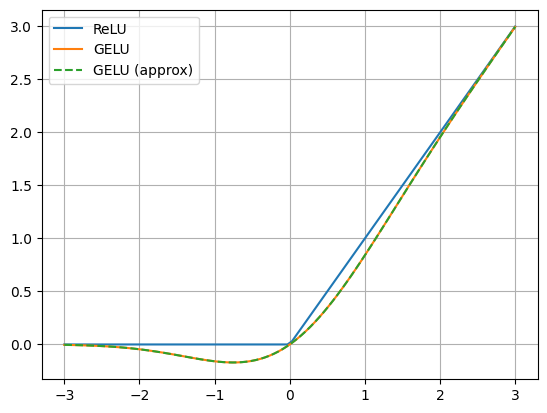

In [50]:
import matplotlib.pyplot as plt

x = torch.linspace(-3, 3, 100)
gelu = torch.nn.GELU()
gelu_approx = torch.nn.GELU(approximate='tanh')

plt.plot(x, torch.relu(x), label='ReLU')
plt.plot(x, gelu(x), label='GELU')
plt.plot(x, gelu_approx(x), '--', label='GELU (approx)')
plt.grid()
plt.legend()
plt.show()




In [52]:
ffn = FeedForward(GPT_CONFIG_124)
x = torch.randn(2, 1024, 768)
y = ffn(x)
print(y.shape)




torch.Size([2, 1024, 768])


### Shortcut Connections

In [ ]:
class ShortcutExampleNN(torch.nn.Module):
    def __init__(self, count_layers: int, use_shortcut: bool):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = torch.nn.ModuleList(
            [
                torch.nn.Sequential(
                    torch.nn.Linear(
                        1 if i == 0 else 5,
                        1 if i == count_layers -1 else 5
                    ),
                    torch.nn.GELU(approximate='tanh')
                )
                for i in range(count_layers)
            ]            
        )

    def forward(self, x: torch.tensor) -> torch.tensor:
        for layer in self.layers:
            if self.use_shortcut:
                x = x + layer(x)
            else:
                x = layer(x)
        return x
    

In [54]:
senn = ShortcutExampleNN(count_layers=5, use_shortcut=True)

x = torch.randn(1)
y = senn(x)
print(y)






tensor([-2.8572e-04,  2.7616e-01, -1.4637e+00, -3.7445e-01, -1.1483e+00],
       grad_fn=<AddBackward0>)


In [55]:
def print_gradient(model, x):
    output = model(x)
    target = torch.tensor([0.])

    loss = torch.nn.MSELoss()
    loss_value = loss(output, target)

    loss_value.backward()

    for name, param in model.named_parameters():
        if param.grad is not None:
            print(name, param.grad.abs().mean())



print_gradient(senn, x)


layers.0.0.weight tensor(0.0811)
layers.0.0.bias tensor(0.0967)
layers.1.0.weight tensor(0.0577)
layers.1.0.bias tensor(0.0743)
layers.2.0.weight tensor(0.0540)
layers.2.0.bias tensor(0.0655)
layers.3.0.weight tensor(0.0859)
layers.3.0.bias tensor(0.1160)
layers.4.0.weight tensor(0.3422)
layers.4.0.bias tensor(0.5259)


/Users/cs/code/starling/.venv/lib/python3.14/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([5])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [56]:
print_gradient(ShortcutExampleNN(count_layers=5, use_shortcut=False), x)


layers.0.0.weight tensor(2.6217e-05)
layers.0.0.bias tensor(3.1275e-05)
layers.1.0.weight tensor(3.2993e-05)
layers.1.0.bias tensor(0.0001)
layers.2.0.weight tensor(0.0001)
layers.2.0.bias tensor(0.0008)
layers.3.0.weight tensor(0.0005)
layers.3.0.bias tensor(0.0045)
layers.4.0.weight tensor(0.0051)
layers.4.0.bias tensor(0.0489)


### Transformer Block

In [58]:
torch.manual_seed(123)

x = torch.randn(2, 1024, 768)

transformer_block = TransformerBlock(GPT_CONFIG_124)
y = transformer_block(x)
print(x.shape)
print(y.shape)


torch.Size([2, 1024, 768])
torch.Size([2, 1024, 768])


### GPT model

In [59]:
GPT_CONFIG_124

{'vocab_size': 50257,
 'block_size': 1024,
 'count_heads': 12,
 'count_blocks': 12,
 'embed_dim': 768,
 'dropout': 0.1,
 'qkv_bias': False}

In [61]:
batch.shape

torch.Size([2, 6, 3])

In [62]:
torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124)

batch = torch.tensor(
    [[6109,  3626,  6100,   345],
     [6109,  1110,  6622,   257]]
)

y = model(batch)
print(batch.shape)
print(y.shape)
print(y)



torch.Size([2, 4])
torch.Size([2, 4, 50257])
tensor([[[ 0.3613,  0.4222, -0.0711,  ...,  0.3483,  0.4661, -0.2838],
         [-0.1792, -0.5660, -0.9485,  ...,  0.0477,  0.5181, -0.3168],
         [ 0.7120,  0.0332,  0.1085,  ...,  0.1018, -0.4327, -0.2553],
         [-1.0076,  0.3418, -0.1190,  ...,  0.7195,  0.4023,  0.0532]],

        [[-0.2564,  0.0900,  0.0335,  ...,  0.2659,  0.4454, -0.6806],
         [ 0.1230,  0.3653, -0.2074,  ...,  0.7705,  0.2710,  0.2246],
         [ 1.0558,  1.0318, -0.2800,  ...,  0.6936,  0.3205, -0.3178],
         [-0.1565,  0.3926,  0.3288,  ...,  1.2630, -0.1858,  0.0388]]],
       grad_fn=<UnsafeViewBackward0>)


In [63]:
total_parameters = sum([p.numel() for p in model.parameters()])
print(f'Total parameters: {total_parameters}')






Total parameters: 163009536


In [64]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

In [65]:
start_text = 'Hello, I am'
encoded = tokenizer.encode(start_text)
print(encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print(encoded_tensor)

model.eval()
out = generate_text_simple(
    model,
    encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124['block_size']
)
print(out)
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

[15496, 11, 314, 716]
tensor([[15496,    11,   314,   716]])
tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 42348,  7267]])
Hello, I am Featureiman Byeswickattribute argue


## LLM Pre-training

In [8]:
GPT_CONFIG_124_local = {
    'vocab_size': 50257,
    'block_size': 256,  # 1024, This makes it possible to train on a normal laptop
    'count_heads': 12,
    'count_blocks': 12,
    'embed_dim': 768,
    'dropout': 0.1,
    'qkv_bias': False,
}

In [12]:
import torch

from sturnus.model import GPTModel

torch.manual_seed(42)

model = GPTModel(GPT_CONFIG_124_local)
model.eval?


Signature: model.eval() -> Self
Docstring:
Set the module in evaluation mode.

This has an effect only on certain modules. See the documentation of
particular modules for details of their behaviors in training/evaluation
mode, i.e. whether they are affected, e.g. :class:`Dropout`, :class:`BatchNorm`,
etc.

This is equivalent with :meth:`self.train(False) <torch.nn.Module.train>`.

See :ref:`locally-disable-grad-doc` for a comparison between
`.eval()` and several similar mechanisms that may be confused with it.

Returns:
    Module: self
File:      ~/code/sturnus/.venv/lib/python3.14/site-packages/torch/nn/modules/module.py
Type:      method

In [68]:
sum([p.numel() for p in model.parameters()])

162419712

In [69]:
def text_to_tokens(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

def tokens_to_text(tokens, tokenizer):
    return tokenizer.decode(tokens.squeeze(0).tolist())

start_text = 'Every effort moves you'
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_tokens(start_text, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124_local['block_size']
)
print('Ouput text:', tokens_to_text(token_ids, tokenizer))




Ouput text: Every effort moves you rentingetic wasnم refres RexMeCHicular stren


### Small example

In [70]:
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                       [40,    1107, 588]])   #  "I really like"]

targets = torch.tensor([[3626, 6100, 345  ],  # [" effort moves you",
                        [1107, 588, 11311]])  #  " really like chocolate"]

In [71]:
with torch.no_grad():     #1
    logits = model(inputs)
probas = torch.softmax(logits, dim=-1)     #2
print(probas.shape)

torch.Size([2, 3, 50257])


In [72]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("Token IDs:\n", token_ids)  


Token IDs:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [73]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 1:", target_probas_1)

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 1: tensor([7.4541e-05, 3.1061e-05, 1.1563e-05])
Text 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


In [74]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [75]:
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


In [76]:
targets.shape

torch.Size([2, 3])

In [77]:
logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)






tensor(10.7940)


In [78]:
loss.item?

Signature: loss.item()
Docstring:
item() -> number

Returns the value of this tensor as a standard Python number. This only works
for tensors with one element. For other cases, see :meth:`~Tensor.tolist`.

This operation is not differentiable.

Example::

    >>> x = torch.tensor([1.0])
    >>> x.item()
    1.0
Type:      builtin_function_or_method

In [79]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(48725.8203)


In [80]:
total_characters = len(text)
total_tokens = len(tokenizer.encode(text))
print(f'Total characters: {total_characters}')
print(f'Total tokens: {total_tokens}')

Total characters: 18136
Total tokens: 7621


In [81]:
### text = text_the_verdict

train_ratio = 0.9
split_idx = int(train_ratio * total_characters)
train_text = text[:split_idx]
val_text = text[split_idx:]
print(f'Train text length: {len(train_text)}')
print(f'Validation text length: {len(val_text)}')




Train text length: 16322
Validation text length: 1814


In [82]:
torch.manual_seed(123)

train_loader = make_data_loader(
    train_text,
    batch_size=2,
    length_max=GPT_CONFIG_124_local['block_size'],
    stride=GPT_CONFIG_124_local['block_size'],
    shuffle=True,
    drop_last=True,
    worker_count=0
)

val_loader = make_data_loader(
    val_text,
    batch_size=2,
    length_max=GPT_CONFIG_124_local['block_size'],
    stride=GPT_CONFIG_124_local['block_size'],
    shuffle=True,
    drop_last=True,
    worker_count=0
)

In [83]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


In [84]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    logits_flat = logits.flatten(0, 1)
    targets_flat = target_batch.flatten()
    loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
    return loss


def calc_loss_loader(dataloader, model, device, batch_count=None):
    total_loss = 0
    if len(dataloader) == 0:
        return float('nan')

    if batch_count is None:
        batch_count = len(dataloader)
    else:
        batch_count = min(batch_count, len(dataloader))

    for i, (input_batch, target_batch) in enumerate(dataloader):
        if i >= batch_count:
            break
        total_loss += calc_loss_batch(input_batch, target_batch, model, device).item()

    return total_loss / batch_count



In [85]:
torch.backends.mps.is_available()

True

In [86]:
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
model.to(device)

with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print(f'Train loss: {train_loss}')
print(f'Validation loss: {val_loss}')






Train loss: 10.943140983581543
Validation loss: 10.91757869720459


In [87]:
device

device(type='mps')

In [88]:
torch.cuda.is_available()

False

In [89]:
def train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    eval_freq,
    eval_iter,
    start_context,
    tokenizer
):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad()
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            loss.backward()
            optimizer.step()
            tokens_seen += input_batch.numel()
            global_step += 1
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(
                    f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, "
                    f"Val loss {val_loss:.3f}"
                )
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )
    
    return train_losses, val_losses, track_tokens_seen






In [90]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, batch_count=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, batch_count=eval_iter)
    model.train()
    return train_loss, val_loss


In [91]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_tokens(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded, max_new_tokens=50, context_size=context_size
        )
    decoded_text = tokens_to_text(token_ids, tokenizer)
    print(decoded_text.replace('\n', ' '))
    model.train()



In [92]:
GPT_CONFIG_124_local

{'vocab_size': 50257,
 'block_size': 256,
 'count_heads': 12,
 'count_blocks': 12,
 'embed_dim': 768,
 'dropout': 0.1,
 'qkv_bias': False}

In [103]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124_local)
model.to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004,
    weight_decay=0.1
)
num_epochs = 100
train_losses, val_losses, tokens_seen = train_model_simple(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    num_epochs,
    eval_freq=10,
    eval_iter=5,
    # start_context='Keiserens største ønske er',
    start_context='Saa begyndte',
    # start_context='Every effort moves you',
    tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.769, Val loss 9.914
Ep 1 (Step 000010): Train loss 5.697, Val loss 6.227
Saa begyndte, og hø, og, og den, og, og, og, og det, og, og det, og, og hø, og hø, og hø
Ep 2 (Step 000020): Train loss 4.127, Val loss 4.903
Saa begyndte hvor det er det var saa kunde den, men saa stille, men saa gikkelige, men saa stille, og saa stille, men saaækkelige,
Ep 3 (Step 000030): Train loss 3.200, Val loss 4.701
Saa begyndte, og de kom, og de kunde, og saa stode Nattergalen, og saa stille Kokke!”  “Denør, der var der skuld
Ep 4 (Step 000040): Train loss 2.532, Val loss 4.710
Ep 4 (Step 000050): Train loss 1.865, Val loss 4.692
Saa begyndte nok, og de ikkelige Nattergal, og den, og de de de kom man, at den fikkelige Nattergalen gikkelige, der var den, o
Ep 5 (Step 000060): Train loss 1.439, Val loss 4.590
Saa begyndte, “Hørt, som kaldes Nattergal!” sagde den!” sagde hørt, men det ved den!” sagde Cavaleren, “jeg skal skuld
Ep 6 (Step 000070): Train loss 0.971, Val loss 4.

In [101]:
train_text[train_text.find('Saa begyndte'):]

'Saa begyndte Nattergalen at synge.\n\n“Den er det,” sagde den lille Pige, “hør! hør! og der sidder den!” og saa pegede hun paa en lille, graa Fugl oppe i Grenene.\n\n“Er det muligt!” sagde Cavaleren, “saaledes havde jeg nu aldrig tænkt mig den! hvor den seer simpel ud! den har vist mistet Couleur over at see saa mange fornemme Mennesker hos sig!”\n\n“Lille Nattergal!” raabte den lille Kokkepige ganske høit, “vor naadige Keiser vil saa gjerne, at De skal synge for ham!”\n\n“Med største Fornøielse!” sagde Nattergalen og sang, saa at det var en Lyst.\n\n“Det er ligesom Glasklokker!” sagde Cavaleren, “og see den lille Strube, hvor den bruger sig! det er mærkværdigt vi aldrig har hørt den før! den vil gjøre en stor succÅs ved Hoffet!”\n\n“Skal jeg synge endnu engang for Keiseren?” spurgte Nattergalen, der troede at Keiseren var med.\n\n“Min fortræffelige lille Nattergal!” sagde Cavaleren, “jeg har den store Glæde at skulle tilsige Dem til en Hoffest i Aften, hvor De vil fortrylle han høie 

In [102]:
val_text[val_text.find('Saa begyndte'):]

'”'

In [ ]:
tokens_seen


[512,
 3072,
 5632,
 8192,
 10752,
 13312,
 15872,
 18432,
 20992,
 23552,
 26112,
 28672,
 31232,
 33792,
 36352,
 38912]